Loaded: Figure3_C_plot_inputs.npz
Plotting only — no UMAP or KMeans is being run.


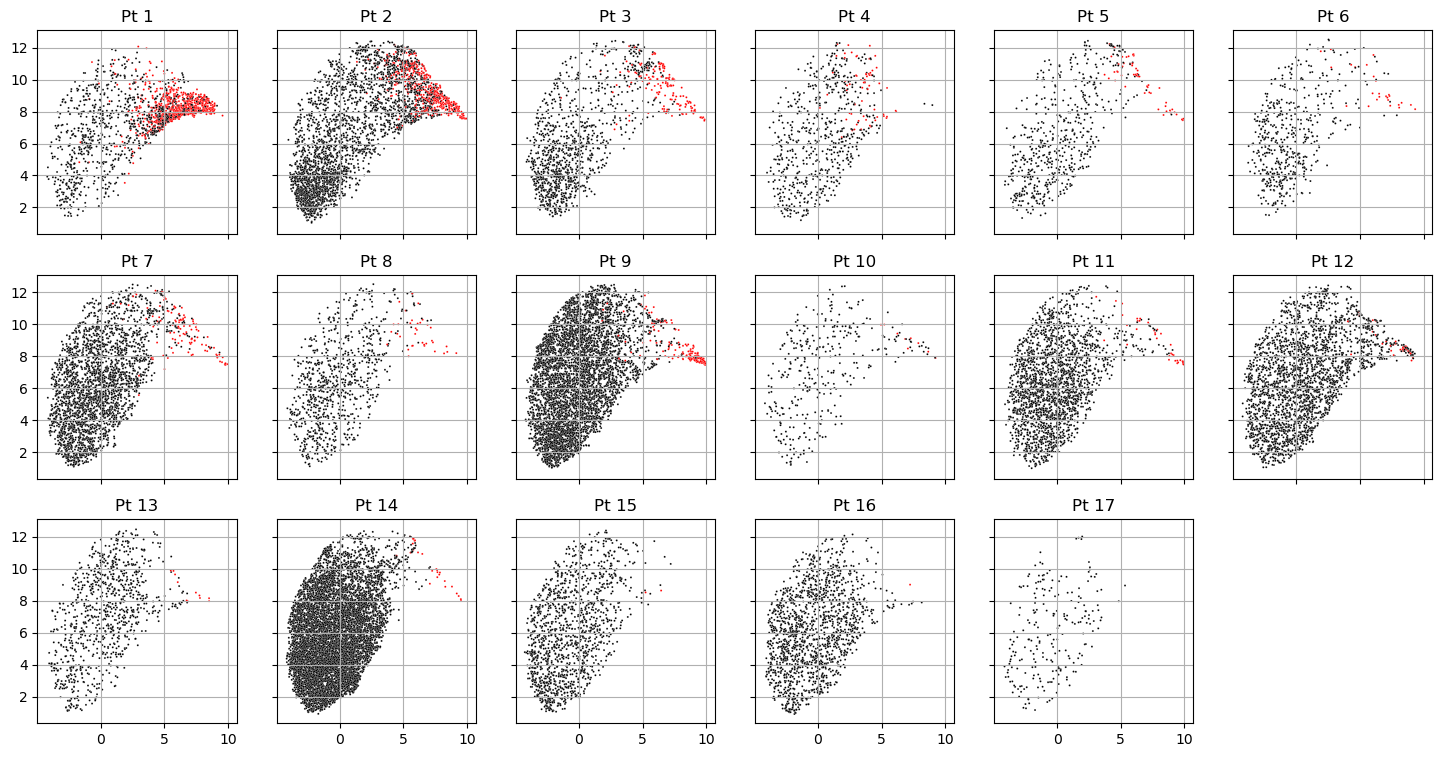

In [1]:
# ============================================================
# PLOT ONLY — START HERE FOR ALL FUTURE REPRODUCTION
#
# No raw .mat loading
# No spike-file loading
# No UMAP
# No KMeans
# No fitting
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CACHE_FILE = "Figure3_C_plot_inputs.npz"

with np.load(CACHE_FILE, allow_pickle=False) as cached:
    embedding = cached["embedding"]
    spike_labels = cached["spike_labels"]
    spec_patient_labels = cached["spec_patient_labels"]
    patient_keys = cached["patient_keys"]
    patient_titles = cached["patient_titles"]

print(f"Loaded: {CACHE_FILE}")
print("Plotting only — no UMAP or KMeans is being run.")

fig, axs = plt.subplots(
    3,
    6,
    figsize=(18, 9),
    sharex=True,
    sharey=True,
)

# Flatten axes for simpler indexing
axs = axs.ravel()

for count, (patient_of_interest, patient_title) in enumerate(
    zip(patient_keys, patient_titles)
):
    mask = spec_patient_labels == patient_of_interest

    each_pt_embedding = embedding[mask]
    each_pt_spikes = spike_labels[mask]

    # Preserve original coloring:
    #   spike == 0 -> black
    #   spike == 1 -> red
    each_pt_color = [
        [0, 0, 0] if spike == 0 else [1, 0, 0]
        for spike in each_pt_spikes
    ]

    ax = sns.scatterplot(
        x=each_pt_embedding[:, 0],
        y=each_pt_embedding[:, 1],
        c=each_pt_color,
        s=2,
        ax=axs[count],
    )

    ax.set_aspect("auto")
    ax.grid(True)
    ax.set_title(patient_title)

# Hide any unused panels, if present
for idx in range(len(patient_keys), len(axs)):
    axs[idx].axis("off")

# Optional:
# plt.savefig(
#     "plot_prob_dots_true_all_patients_200_new.png",
#     dpi=1200,
#     bbox_inches="tight",
# )

plt.show()
